In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

#Load the dataset

In [2]:
#Load Dataset
(ds_train,ds_val,ds_test),info=tfds.load(
    'tf_flowers',
    split=['train[:70%]','train[70%:85%]','train[85%:]'],
    as_supervised=True,
    with_info=True
)
NUM_CLASSES=info.features['label'].num_classes
CLASS_NAMES=info.features['label'].names



Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.STZ2ML_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [3]:
CLASS_NAMES

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

#Preprocessing the dataset

In [4]:
IMG_SIZE=224
BATCH_SIZE=32

def preprocess(image,label):
  image=tf.image.resize(image,(IMG_SIZE,IMG_SIZE))
  image=tf.keras.applications.mobilenet_v2.preprocess_input(image)
  return image,label

train_ds=ds_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE)
val_ds=ds_val.map(preprocess).batch(BATCH_SIZE)
test_ds=ds_test.map(preprocess).batch(BATCH_SIZE)

#Data Augementation

In [5]:
data_augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)

])

#Creating the basemodel

In [6]:
base_model=tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE,IMG_SIZE,3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable=False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#Build the sequential model

In [7]:
from tensorflow.keras import models
from tensorflow.keras.layers import Dense,Flatten,Dropout,GlobalAveragePooling2D



In [8]:
model=models.Sequential()
#Adding augmentation
model.add(data_augmentation)
#Adding Base model
model.add(base_model)

#Add classification head
model.add(GlobalAveragePooling2D())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(NUM_CLASSES,activation='softmax'))
#

In [9]:
model.build(input_shape=(None, 224, 224, 3))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [11]:
history=model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds
)

Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.7341 - loss: 0.7113 - val_accuracy: 0.8457 - val_loss: 0.4055
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.8529 - loss: 0.3992 - val_accuracy: 0.8711 - val_loss: 0.3756
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.8696 - loss: 0.3537 - val_accuracy: 0.8838 - val_loss: 0.3276
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.8883 - loss: 0.3100 - val_accuracy: 0.8820 - val_loss: 0.3150
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.9058 - loss: 0.2557 - val_accuracy: 0.8893 - val_loss: 0.3284
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.9128 - loss: 0.2423 - val_accuracy: 0.8820 - val_loss: 0.3298
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.9229 - loss: 0.2200 - val_accuracy: 0.8784 - val_loss: 0.3328
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.9272 - loss: 0.1959 - val_accuracy: 0.8766 

#Fine tuning the model

🎯 Simple Summary

👉 Phase 1: Train only new layers while freezing pretrained model

👉 Phase 2: Unfreeze top layers and fine-tune with a low learning rate

In [12]:
base_model.trainable=True

for layers in base_model.layers[:-30]:
  layers.trainable=False

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(1e-5),
    metrics=['accuracy']
)

In [13]:
history2 = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds
)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - accuracy: 0.8046 - loss: 0.6866 - val_accuracy: 0.8784 - val_loss: 0.4805
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.8898 - loss: 0.3317 - val_accuracy: 0.8711 - val_loss: 0.5268
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.9089 - loss: 0.2784 - val_accuracy: 0.8784 - val_loss: 0.5180
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.9163 - loss: 0.2327 - val_accuracy: 0.8820 - val_loss: 0.5064
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.9225 - loss: 0.2288 - val_accuracy: 0.8802 - val_loss: 0.4785
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.9342 - loss: 0.1864 - val_accuracy: 0.8893 - val_loss: 0.4558
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.9420 - loss: 0.1586 - val_accuracy: 0.8857 - val_loss: 0.4672
Epoch 8/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.9389 - loss: 0.1639 - val_accuracy: 0.8857 

#Evaluating

In [14]:
loss,acc=model.evaluate(test_ds)
print("Model Accuracy: ",acc )

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9200 - loss: 0.3092
Model Accuracy:  0.9200000166893005


In [15]:
def show_predictions(data):
  images, labels = next(iter(data))
  preds=model.predict(images)
  pred_labels=np.argmax(preds,axis=1)
  print(preds)
  print(pred_labels)

show_predictions(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[3.27239092e-03 6.32338941e-01 3.48557919e-01 1.03806713e-04
  1.57269519e-02]
 [9.99985218e-01 8.78291146e-08 3.96569853e-08 1.46052571e-05
  4.23804429e-11]
 [9.99960184e-01 5.29406009e-07 3.60050137e-07 3.89790730e-05
  3.79542193e-08]
 [1.43338629e-12 3.54435925e-11 9.99894500e-01 3.97488493e-13
  1.05479652e-04]
 [4.82531168e-11 1.70101441e-06 9.99997854e-01 2.47061482e-10
  5.22420748e-07]
 [3.08951087e-07 9.99993205e-01 1.83767224e-09 2.78263954e-08
  6.47296019e-06]
 [1.33703309e-11 1.00000000e+00 8.80377507e-11 5.56953754e-11
  8.40710057e-10]
 [3.98474513e-05 5.56197210e-06 1.62660360e-01 8.89094896e-04
  8.36405098e-01]
 [3.59614521e-01 3.77519667e-04 3.26085537e-05 6.39778197e-01
  1.97077185e-04]
 [2.22535688e-11 5.06222078e-11 8.47858761e-09 1.00000000e+00
  4.50846749e-10]
 [1.60648227e-07 4.18112868e-05 9.99957919e-01 1.14124987e-07
  1.31058187e-08]
 [9.99876261e-01 6.32459924e-05 3.41300925e-08 4.18195981e-07
  5.98976985e-05]
 [1.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


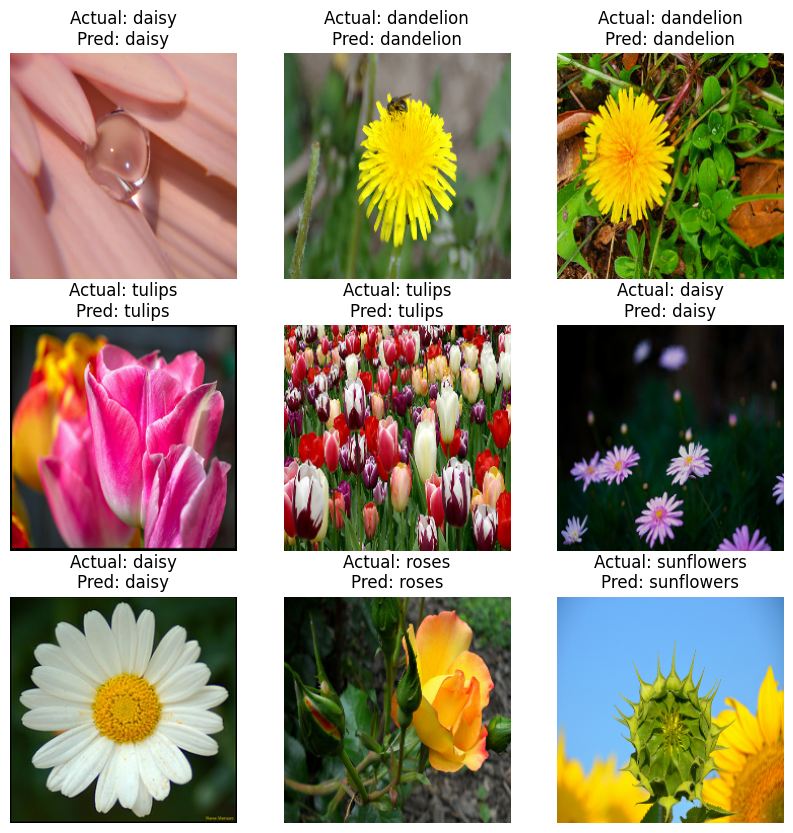

In [16]:
def show_predictions_p(dataset):
    images, labels = next(iter(dataset))
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(10,10))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow((images[i] + 1) / 2)  # fix display
        plt.title(
            f"Actual: {CLASS_NAMES[labels[i]]}\n"
            f"Pred: {CLASS_NAMES[pred_labels[i]]}"
        )

        plt.axis('off')
    plt.show()

show_predictions_p(test_ds)

In [17]:
model.save("flower_model.h5")